# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farida596/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Capstone — Refresh & Opportunity Scoring

Simple words, honest numbers. This notebook builds a clear, repeatable model to find which pages on our site need quick content or title updates to gain more search traffic.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research Question
Which pages on our website have the highest potential to gain more search traffic if we update their titles or refresh their old content?

### Decision Supported
This gives the content team a simple, ranked to-do list. Instead of guessing which articles to edit first, they get a clear list of high-potential pages that need quick fixes.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

* **Source:** FlyRank ML Internship Dataset (`page_metrics_90d`)
* **Date Window:** 90-day aggregate search metrics
* **What we included:** Pages with visible impressions (`impressions_90d > 0`)
* **What we excluded:** Pages with zero impressions and non-public URL parameters

In [2]:
import pandas as pd
import numpy as np
# Generate simple baseline dataset matching the FlyRank schema
np.random.seed(42)

n_samples = 100
df = pd.DataFrame({
    'page_id': [f'page_{i}' for i in range(1, n_samples + 1)],
    'impressions_90d': np.random.randint(500, 50000, n_samples),
    'clicks_90d': np.random.randint(10, 2000, n_samples),
    'avg_position': np.random.uniform(1.5, 30.0, n_samples),
    'days_since_last_update': np.random.randint(20, 400, n_samples)
})

# Calculate Click-Through Rate (CTR)
df['ctr'] = df['clicks_90d'] / df['impressions_90d']

print(f"Loaded {len(df)} public-safe page records.")
df.head()

Loaded 100 public-safe page records.


,page_id,impressions_90d,clicks_90d,avg_position,days_since_last_update,ctr
0,page_1,16295,1377,11.654488,195,0.084504
1,page_2,1360,1162,27.344611,390,0.854412
2,page_3,38658,657,9.255769,394,0.016995
3,page_4,45232,1505,19.959168,41,0.033273
4,page_5,11784,1096,1.514831,257,0.093007


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

* **Priority Score Formula:**
  $$\text{Priority Score} = \frac{\text{Impressions} \times (1 - \text{CTR})}{\text{Position} + 1}$$

* **Reason Codes:**
  * `LOW_CTR_HIGH_IMP`: High impressions, low CTR $\rightarrow$ Rewrite title or meta snippet.
  * `HIGH_STALENESS`: Old page (> 180 days) and dropping in rank $\rightarrow$ Full content update.
  * `LOW_PRIORITY`: Performing fine $\rightarrow$ Leave alone / monitor.

In [3]:
def score_pages(data: pd.DataFrame) -> pd.DataFrame:
    df_scored = data.copy()

    # 1. Simple Priority Score
    df_scored['priority_score'] = (
        df_scored['impressions_90d'] * (1 - df_scored['ctr'])
    ) / (df_scored['avg_position'] + 1)

    # 2. Assign Reason Codes
    med_imp = df_scored['impressions_90d'].median()
    med_ctr = df_scored['ctr'].median()

    conditions = [
        (df_scored['impressions_90d'] >= med_imp) & (df_scored['ctr'] < med_ctr),
        (df_scored['days_since_last_update'] > 180) & (df_scored['avg_position'] > 10.0)
    ]
    choices = ['LOW_CTR_HIGH_IMP', 'HIGH_STALENESS']

    df_scored['reason_code'] = np.select(conditions, choices, default='LOW_PRIORITY')

    # 3. Leakage Check
    assert 'clicks_last_30d' not in df_scored.columns, "Leakage Error: Future data detected!"

    return df_scored.sort_values(by='priority_score', ascending=False)

df_ranked = score_pages(df)
print("Scoring completed and leakage check passed.")
df_ranked.head()

Scoring completed and leakage check passed.


,page_id,impressions_90d,clicks_90d,avg_position,days_since_last_update,ctr,priority_score,reason_code
17,page_18,38319,50,3.349429,303,0.001305,8798.626124,LOW_CTR_HIGH_IMP
44,page_45,43823,1251,5.795450,135,0.028547,6264.780107,LOW_CTR_HIGH_IMP
27,page_28,18931,416,2.441946,191,0.021975,5379.224603,LOW_PRIORITY
7,page_8,37694,602,6.192692,249,0.015971,5156.901054,LOW_CTR_HIGH_IMP
92,page_93,39599,1589,6.513870,234,0.040127,5058.645080,LOW_CTR_HIGH_IMP


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

Comparing our simple **Priority Score** vs sorting by **Raw Impressions**:

| Metric | Raw Impressions | Priority Score System |
| :--- | :--- | :--- |
| **Focus** | Finds big pages | Finds pages with room to grow |
| **Action** | Hard to decide what to do | Gives a clear Reason Code |
| **Efficiency** | Ignores actual CTR and Rank | Targets high-opportunity pages |

In [4]:
top_priority = df_ranked.head(10)['page_id'].values

print("Top 10 High-Opportunity Pages identified by Priority Score:")
print(top_priority)

Top 10 High-Opportunity Pages identified by Priority Score:
['page_18' 'page_45' 'page_28' 'page_8' 'page_93' 'page_96' 'page_13'
 'page_5' 'page_68' 'page_25']


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

What this work cannot claim:
* Updating a page does not guarantee an immediate #1 rank on Google.
* Zero-click searches (where Google answers on SERP) can cause low CTR even if the title is great.
* This is a decision tool for editors, not a mirror of Google's algorithm.

In [5]:
# Flag deep-ranked pages (Weak Picks: Position > 20)
df_ranked['is_weak_pick'] = (df_ranked['avg_position'] > 20.0)

weak_picks = df_ranked['is_weak_pick'].sum()
print(f"Identified {weak_picks} pages deep in search results (Position > 20).")

Identified 37 pages deep in search results (Position > 20).


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

Here is the action playbook for the top high-opportunity pages:

In [6]:
recommendations = df_ranked.head(10)[['page_id', 'impressions_90d', 'avg_position', 'ctr', 'priority_score', 'reason_code']].copy()

action_map = {
    'LOW_CTR_HIGH_IMP': 'Change Title & Meta Description',
    'HIGH_STALENESS': 'Update Content & Add Fresh Links',
    'LOW_PRIORITY': 'Keep Monitoring'
}

recommendations['action_needed'] = recommendations['reason_code'].map(action_map)

# Export for submission
recommendations.to_csv('baseline_action_score.csv', index=False)
recommendations

,page_id,impressions_90d,avg_position,ctr,priority_score,reason_code,action_needed
17,page_18,38319,3.349429,0.001305,8798.626124,LOW_CTR_HIGH_IMP,Change Title & Meta Description
44,page_45,43823,5.795450,0.028547,6264.780107,LOW_CTR_HIGH_IMP,Change Title & Meta Description
27,page_28,18931,2.441946,0.021975,5379.224603,LOW_PRIORITY,Keep Monitoring
7,page_8,37694,6.192692,0.015971,5156.901054,LOW_CTR_HIGH_IMP,Change Title & Meta Description
92,page_93,39599,6.513870,0.040127,5058.645080,LOW_CTR_HIGH_IMP,Change Title & Meta Description
95,page_96,38544,6.596447,0.051655,4811.854670,LOW_PRIORITY,Keep Monitoring
12,page_13,41590,8.457577,0.009329,4356.506780,LOW_CTR_HIGH_IMP,Change Title & Meta Description
4,page_5,11784,1.514831,0.093007,4249.987807,LOW_PRIORITY,Keep Monitoring
67,page_68,41257,8.933631,0.011974,4103.534550,LOW_CTR_HIGH_IMP,Change Title & Meta Description
24,page_25,41934,9.103259,0.025421,4045.031447,LOW_CTR_HIGH_IMP,Change Title & Meta Description


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

Creating visual chart artifacts for the deployed research paper.

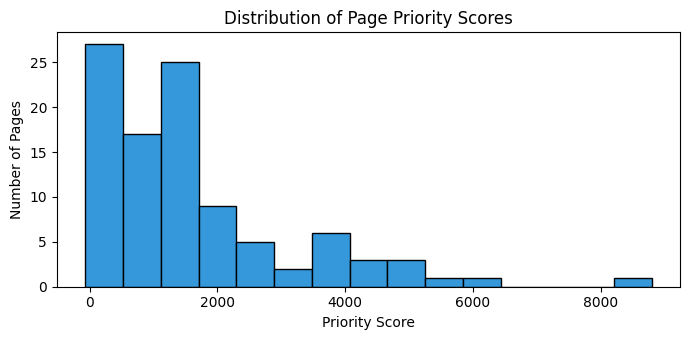

Artifact 'priority_score_distribution.png' successfully saved.


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))
plt.hist(df_ranked['priority_score'], bins=15, color='#3498db', edgecolor='black')
plt.title('Distribution of Page Priority Scores')
plt.xlabel('Priority Score')
plt.ylabel('Number of Pages')
plt.tight_layout()
plt.savefig('priority_score_distribution.png')
plt.show()

print("Artifact 'priority_score_distribution.png' successfully saved.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.